In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import plotly.express as px 
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [81]:
final_data = pd.read_csv('final-data.csv')

In [82]:
final_data

,instant,dateday,season,month,hour,holiday,weekday,weathersit,temp,atemp,humidity,windspeed,casual,registered,count
0,1,2011-01-01,1,1,0,False,6,1,0.24,0.2879,0.81,0.0000,3,13,16
1,2,2011-01-01,1,1,1,False,6,1,0.22,0.2727,0.80,0.0000,8,32,40
2,3,2011-01-01,1,1,2,False,6,1,0.22,0.2727,0.80,0.0000,5,27,32
3,4,2011-01-01,1,1,3,False,6,1,0.24,0.2879,0.75,0.0000,3,10,13
4,5,2011-01-01,1,1,4,False,6,1,0.24,0.2879,0.75,0.0000,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,615,2011-01-28,1,1,20,False,5,2,0.24,0.2273,0.70,0.1940,1,61,62
996,616,2011-01-28,1,1,21,False,5,2,0.22,0.2273,0.75,0.1343,1,57,58
997,617,2011-01-28,1,1,22,False,5,1,0.24,0.2121,0.65,0.3582,0,26,26
998,618,2011-01-28,1,1,23,False,5,1,0.24,0.2273,0.60,0.2239,1,22,23


In [83]:
final_data.isnull().sum()

instant       0
dateday       0
season        0
month         0
hour          0
holiday       0
weekday       0
weathersit    0
temp          0
atemp         0
humidity      0
windspeed     0
casual        0
registered    0
count         0
dtype: int64

In [84]:
final_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     1000 non-null   int64  
 1   dateday     1000 non-null   object 
 2   season      1000 non-null   int64  
 3   month       1000 non-null   int64  
 4   hour        1000 non-null   int64  
 5   holiday     1000 non-null   bool   
 6   weekday     1000 non-null   int64  
 7   weathersit  1000 non-null   int64  
 8   temp        1000 non-null   float64
 9   atemp       1000 non-null   float64
 10  humidity    1000 non-null   float64
 11  windspeed   1000 non-null   float64
 12  casual      1000 non-null   int64  
 13  registered  1000 non-null   int64  
 14  count       1000 non-null   int64  
dtypes: bool(1), float64(4), int64(9), object(1)
memory usage: 110.5+ KB


Here we have changed the datatype of the dateday because the datatype of the dateday column is showing the object, so we have changed it to datetimes.

In [85]:

final_data['dateday'] = pd.to_datetime(final_data['dateday'])


In [86]:
final_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     1000 non-null   int64         
 1   dateday     1000 non-null   datetime64[ns]
 2   season      1000 non-null   int64         
 3   month       1000 non-null   int64         
 4   hour        1000 non-null   int64         
 5   holiday     1000 non-null   bool          
 6   weekday     1000 non-null   int64         
 7   weathersit  1000 non-null   int64         
 8   temp        1000 non-null   float64       
 9   atemp       1000 non-null   float64       
 10  humidity    1000 non-null   float64       
 11  windspeed   1000 non-null   float64       
 12  casual      1000 non-null   int64         
 13  registered  1000 non-null   int64         
 14  count       1000 non-null   int64         
dtypes: bool(1), datetime64[ns](1), float64(4), int64(9)
memory usage: 110.5 K

In [87]:
#here i am detect outliers from the data set

In [88]:
final_data['count'].value_counts()

count
1      45
2      38
3      34
5      19
7      17
       ..
153     1
238     1
219     1
225     1
149     1
Name: count, Length: 191, dtype: int64

In [89]:
final_data.shape

(1000, 15)

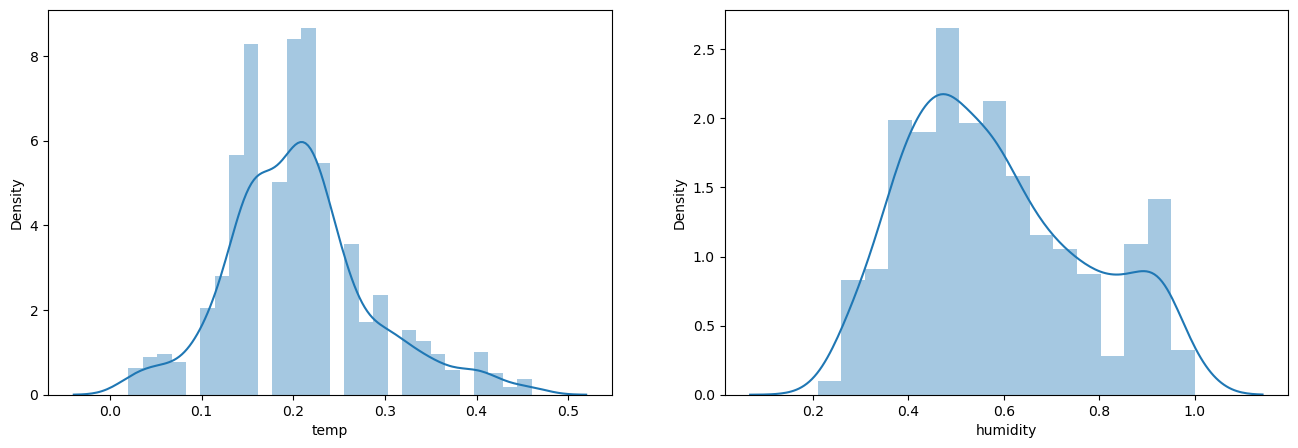

<Axes: >

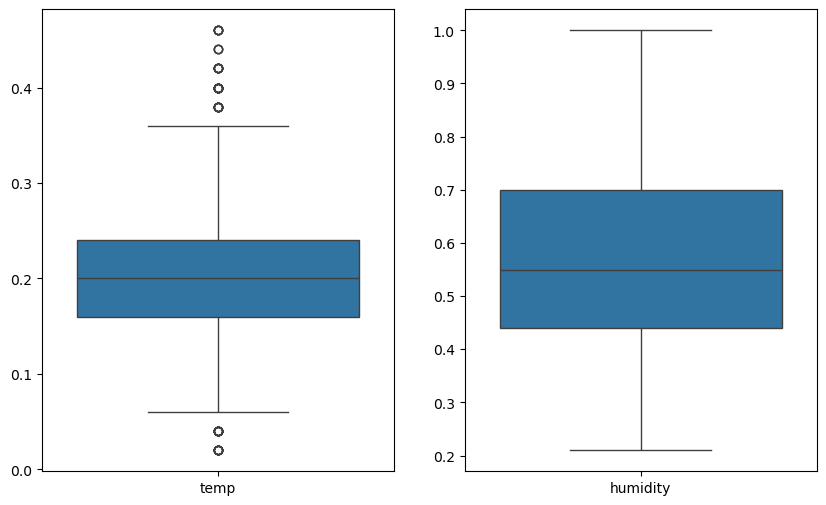

In [90]:
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.distplot(final_data['temp'])

plt.subplot(1,2,2)
sns.distplot(final_data['humidity'])
plt.show()

fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(10,6))
sns.boxplot(data=final_data[['temp']],ax=ax1)
sns.boxplot(data=final_data[['humidity']],ax=ax2)

In [91]:
#We found some outliers through Boxplot

#Here we have used the IQR method to detect the outliers.

In [92]:
final_data['temp'].skew()

0.5479968824203467

In [93]:
final_data['temp'].describe()

count    1000.000000
mean        0.205900
std         0.078977
min         0.020000
25%         0.160000
50%         0.200000
75%         0.240000
max         0.460000
Name: temp, dtype: float64

In [94]:
print("Mean value of temp",final_data["temp"].mean())
print("std value of temp",final_data["temp"].std())

Mean value of temp 0.20590000000000003
std value of temp 0.07897738554439107


In [95]:
Q1 = final_data['temp'].quantile(0.25)
Q3 = final_data['temp'].quantile(0.75)
IQR = Q3-Q1
upper_limit = Q3 + 1.5*IQR
lower_limit = Q1 - 1.5*IQR

print(Q1)
print(Q3)
print(IQR)
print(upper_limit)
print(lower_limit)

0.16
0.24
0.07999999999999999
0.36
0.04000000000000002


In [96]:
final_data[final_data['temp']>upper_limit]

,instant,dateday,season,month,hour,holiday,weekday,weathersit,temp,atemp,humidity,windspeed,casual,registered,count
10,11,2011-01-01,1,1,10,False,6,1,0.38,0.3939,0.76,0.2537,12,24,36
12,13,2011-01-01,1,1,12,False,6,1,0.42,0.4242,0.77,0.2836,29,55,84
13,14,2011-01-01,1,1,13,False,6,2,0.46,0.4545,0.72,0.2985,47,47,94
14,15,2011-01-01,1,1,14,False,6,2,0.46,0.4545,0.72,0.2836,35,71,106
15,16,2011-01-01,1,1,15,False,6,2,0.44,0.4394,0.77,0.2985,40,70,110
16,17,2011-01-01,1,1,16,False,6,2,0.42,0.4242,0.82,0.2985,41,52,93
17,18,2011-01-01,1,1,17,False,6,2,0.44,0.1970,0.82,0.2836,15,52,67
18,19,2011-01-01,1,1,18,False,6,3,0.42,0.4242,0.88,0.2537,9,26,35
19,20,2011-01-01,1,1,19,False,6,3,0.42,0.4242,0.88,0.2537,6,31,37
20,21,2011-01-01,1,1,20,False,6,2,0.40,0.4091,0.87,0.2537,11,25,36


In [97]:
final_data[final_data['temp']<lower_limit]

,instant,dateday,season,month,hour,holiday,weekday,weathersit,temp,atemp,humidity,windspeed,casual,registered,count
479,480,2011-01-22,1,1,0,False,6,1,0.04,0.0303,0.45,0.2537,0,13,13
480,481,2011-01-22,1,1,1,False,6,2,0.04,0.0000,0.41,0.3881,3,9,12
481,482,2011-01-22,1,1,2,False,6,2,0.04,0.0303,0.41,0.2537,0,11,11
482,483,2011-01-22,1,1,3,False,6,2,0.04,0.0303,0.41,0.2836,1,6,7
483,484,2011-01-22,1,1,4,False,6,2,0.02,0.0152,0.48,0.2985,0,3,3
484,485,2011-01-22,1,1,6,False,6,2,0.02,0.0303,0.44,0.2239,0,2,2
485,486,2011-01-22,1,1,7,False,6,1,0.02,0.0152,0.44,0.2836,0,8,8
486,487,2011-01-22,1,1,8,False,6,1,0.02,0.0000,0.44,0.3284,1,26,27
487,488,2011-01-22,1,1,9,False,6,1,0.04,0.0303,0.41,0.2537,3,37,40
488,489,2011-01-22,1,1,10,False,6,2,0.04,0.0606,0.41,0.1642,3,50,53


In [98]:
#here i have capping the outlier using the np.where function

In [99]:
final_data["temp"]=np.where(
    final_data["temp"]>upper_limit,
    upper_limit,
    np.where(
        final_data["temp"]<lower_limit,
                         lower_limit,
        final_data["temp"]))

In [100]:
#After capping you can see that the outliers have been capped.

<Axes: xlabel='temp'>

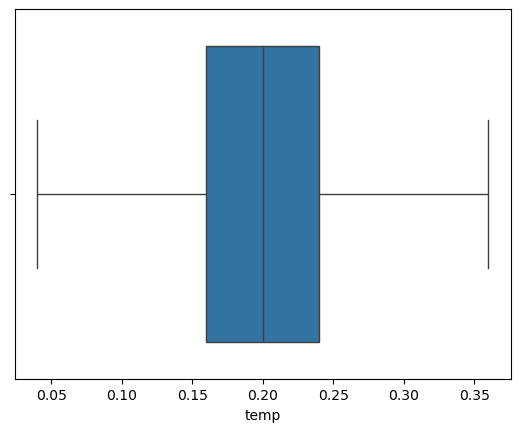

In [101]:
sns.boxplot(x=final_data['temp'])

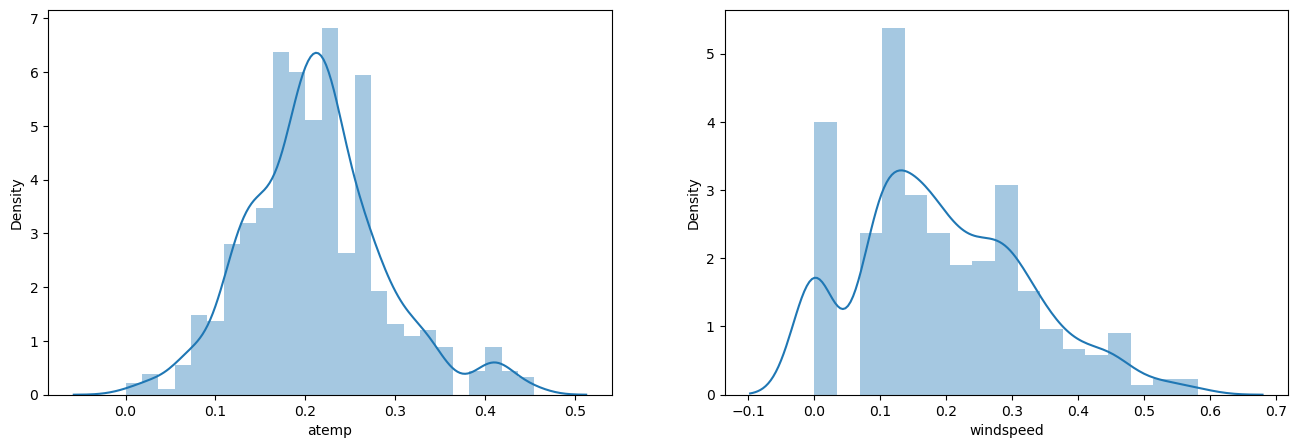

<Axes: >

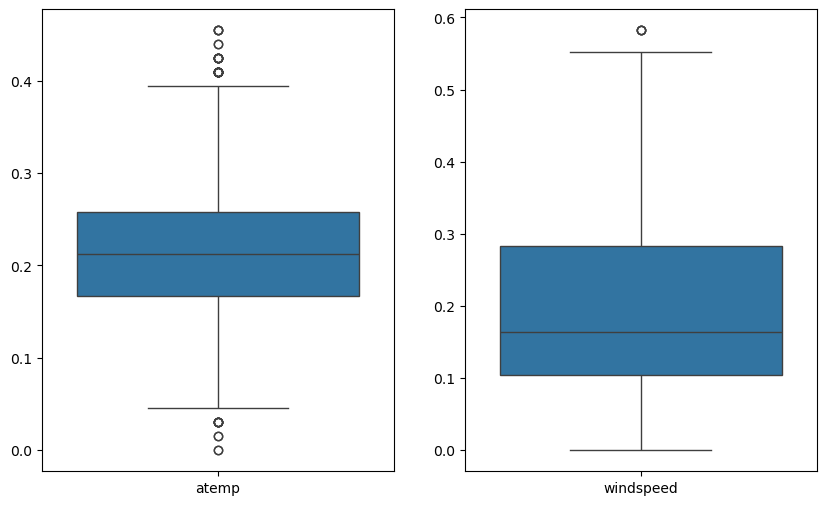

In [102]:
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.distplot(final_data['atemp'])

plt.subplot(1,2,2)
sns.distplot(final_data['windspeed'])
plt.show()

fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(10,6))
sns.boxplot(data=final_data[['atemp']],ax=ax1)
sns.boxplot(data=final_data[['windspeed']],ax=ax2)

In [103]:
final_data['atemp'].describe()

count    1000.000000
mean        0.211793
std         0.076295
min         0.000000
25%         0.166700
50%         0.212100
75%         0.257600
max         0.454500
Name: atemp, dtype: float64

In [104]:
final_data['atemp'].skew()

0.43706246595440107

In [105]:
print("Mean value of atemp",final_data["atemp"].mean())
print("std value of atemp",final_data["atemp"].std())

Mean value of atemp 0.2117933
std value of atemp 0.07629540677002926


In [106]:
Q1 = final_data['atemp'].quantile(0.25)
Q3 = final_data['atemp'].quantile(0.75)
IQR = Q3-Q1
upper_limit = Q3 + 1.5*IQR
lower_limit = Q1 - 1.5*IQR

print(Q1)
print(Q3)
print(IQR)
print(upper_limit)
print(lower_limit)

0.1667
0.2576
0.09090000000000001
0.39395
0.03034999999999996


In [107]:
final_data[final_data['atemp']>upper_limit]

,instant,dateday,season,month,hour,holiday,weekday,weathersit,temp,atemp,humidity,windspeed,casual,registered,count
12,13,2011-01-01,1,1,12,False,6,1,0.36,0.4242,0.77,0.2836,29,55,84
13,14,2011-01-01,1,1,13,False,6,2,0.36,0.4545,0.72,0.2985,47,47,94
14,15,2011-01-01,1,1,14,False,6,2,0.36,0.4545,0.72,0.2836,35,71,106
15,16,2011-01-01,1,1,15,False,6,2,0.36,0.4394,0.77,0.2985,40,70,110
16,17,2011-01-01,1,1,16,False,6,2,0.36,0.4242,0.82,0.2985,41,52,93
18,19,2011-01-01,1,1,18,False,6,3,0.36,0.4242,0.88,0.2537,9,26,35
19,20,2011-01-01,1,1,19,False,6,3,0.36,0.4242,0.88,0.2537,6,31,37
20,21,2011-01-01,1,1,20,False,6,2,0.36,0.4091,0.87,0.2537,11,25,36
21,22,2011-01-01,1,1,21,False,6,2,0.36,0.4091,0.87,0.1940,3,31,34
22,23,2011-01-01,1,1,22,False,6,2,0.36,0.4091,0.94,0.2239,11,17,28


In [108]:
final_data[final_data['temp']>lower_limit]

,instant,dateday,season,month,hour,holiday,weekday,weathersit,temp,atemp,humidity,windspeed,casual,registered,count
0,1,2011-01-01,1,1,0,False,6,1,0.24,0.2879,0.81,0.0000,3,13,16
1,2,2011-01-01,1,1,1,False,6,1,0.22,0.2727,0.80,0.0000,8,32,40
2,3,2011-01-01,1,1,2,False,6,1,0.22,0.2727,0.80,0.0000,5,27,32
3,4,2011-01-01,1,1,3,False,6,1,0.24,0.2879,0.75,0.0000,3,10,13
4,5,2011-01-01,1,1,4,False,6,1,0.24,0.2879,0.75,0.0000,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,615,2011-01-28,1,1,20,False,5,2,0.24,0.2273,0.70,0.1940,1,61,62
996,616,2011-01-28,1,1,21,False,5,2,0.22,0.2273,0.75,0.1343,1,57,58
997,617,2011-01-28,1,1,22,False,5,1,0.24,0.2121,0.65,0.3582,0,26,26
998,618,2011-01-28,1,1,23,False,5,1,0.24,0.2273,0.60,0.2239,1,22,23


In [109]:
final_data["atemp"]=np.where(
    final_data["atemp"]>upper_limit,
    upper_limit,
    np.where(
        final_data["atemp"]<lower_limit,
                         lower_limit,
        final_data["atemp"]))

<Axes: xlabel='atemp'>

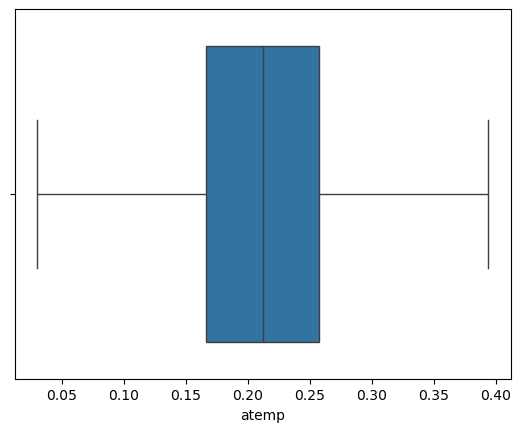

In [110]:
sns.boxplot(x=final_data['atemp'])

In [111]:
#here i have applied Z-squre formula of 'windspeed' column

In [112]:
final_data['windspeed'].describe()

count    1000.000000
mean        0.194931
std         0.129126
min         0.000000
25%         0.104500
50%         0.164200
75%         0.283600
max         0.582100
Name: windspeed, dtype: float64

In [113]:
final_data['windspeed'].skew()

0.43367506246878307

In [114]:
mean_value = final_data['windspeed'].mean()
stnd_deviation = final_data['windspeed'].std()

In [115]:
mean_value,stnd_deviation

(0.19493129999999997, 0.1291260662736276)

In [116]:
max_value = final_data['windspeed'].mean() + 3*final_data['windspeed'].std()
min_value = final_data['windspeed'].mean() - 3*final_data['windspeed'].std()

In [117]:
max_value,min_value

(0.5823094988208828, -0.19244689882088284)

Finding ouliers

In [118]:
final_data[(final_data['windspeed']>0.58) | (final_data['windspeed']<-0.19)]

,instant,dateday,season,month,hour,holiday,weekday,weathersit,temp,atemp,humidity,windspeed,casual,registered,count
265,266,2011-01-12,1,1,12,False,3,1,0.20,0.1515,0.47,0.5821,3,52,55
467,468,2011-01-21,1,1,12,False,5,1,0.22,0.1818,0.27,0.5821,11,67,78
468,469,2011-01-21,1,1,13,False,5,1,0.20,0.1515,0.21,0.5821,8,65,73
861,871,2011-02-08,1,2,17,False,2,1,0.22,0.1818,0.32,0.5821,4,172,176


In [119]:
final_data['windspeed'] = np.where(
    final_data['windspeed']> max_value,
    max_value,
    
    np.where(
        final_data['windspeed']<min_value,
        min_value,
        
        final_data['windspeed']
    )

)

In [120]:
#here i am finding the outliers of the columns 'casual','register'

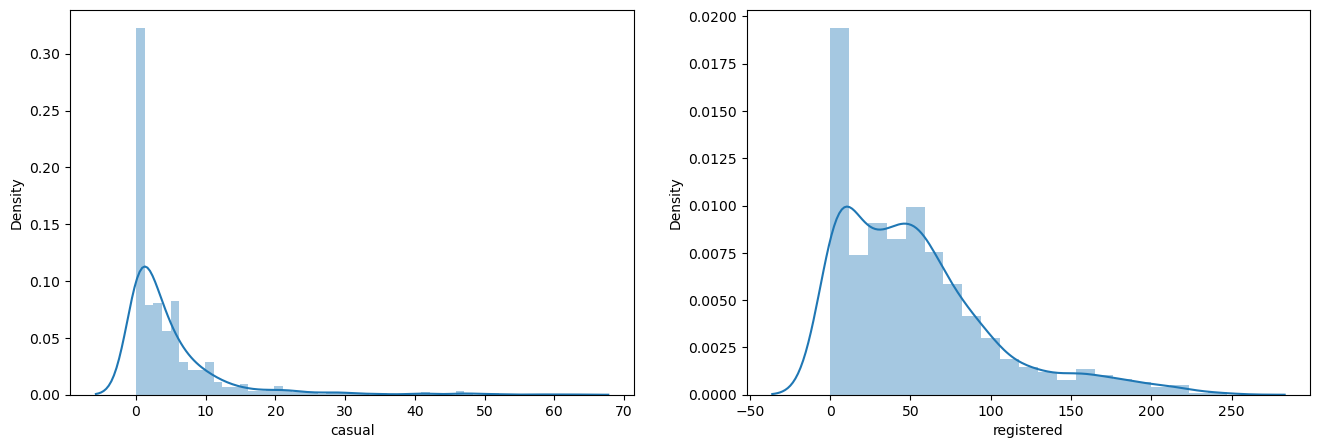

<Axes: >

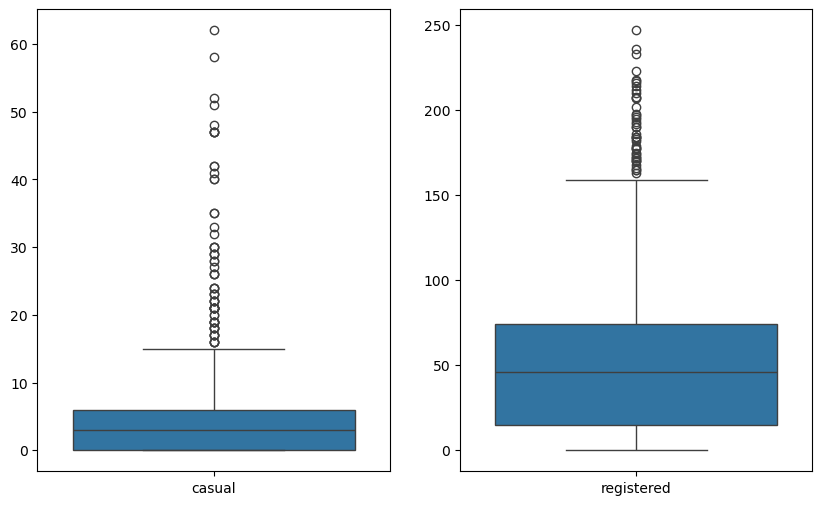

In [121]:
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.distplot(final_data['casual'])

plt.subplot(1,2,2)
sns.distplot(final_data['registered'])
plt.show()

fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(10,6))
sns.boxplot(data=final_data[['casual']],ax=ax1)
sns.boxplot(data=final_data[['registered']],ax=ax2)

In [122]:
#here again i am using IQR formula thats why data are skew is right and i can see boxplot outliers are there

In [123]:
final_data['casual'].skew()

3.4141050413066423

In [124]:
final_data['casual'].describe()

count    1000.000000
mean        4.921000
std         7.643899
min         0.000000
25%         0.000000
50%         3.000000
75%         6.000000
max        62.000000
Name: casual, dtype: float64

In [125]:
print("Mean value of casual",final_data["casual"].mean())
print("std deviation of casual",final_data["casual"].std())

Mean value of casual 4.921
std deviation of casual 7.643898755752074


In [126]:
Q1 = final_data['casual'].quantile(0.25)
Q3 = final_data['casual'].quantile(0.75)
IQR = Q3-Q1
upper_limit = Q3 + 1.5*IQR
lower_limit = Q1 - 1.5*IQR

print(Q1)
print(Q3)
print(IQR)
print(upper_limit)
print(lower_limit)

0.0
6.0
6.0
15.0
-9.0


In [127]:
final_data["casual"]=np.where(
    final_data["casual"]>upper_limit,
    upper_limit,
    np.where(
        final_data["casual"]<lower_limit,
                         lower_limit,
        final_data["casual"]))

<Axes: xlabel='casual'>

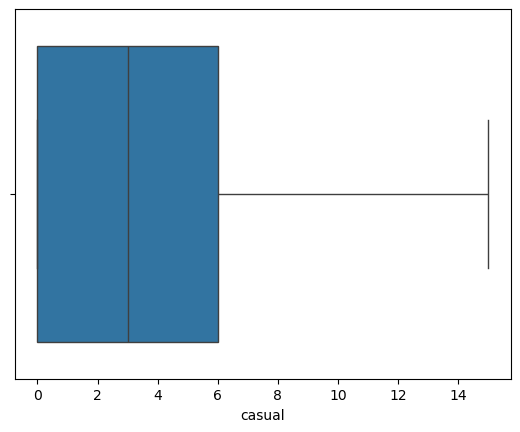

In [128]:
sns.boxplot(x=final_data['casual'])

In [129]:
#We will do the same process with the registered columns.

In [130]:
final_data['registered'].describe()

count    1000.000000
mean       53.383000
std        47.893968
min         0.000000
25%        15.000000
50%        46.000000
75%        74.000000
max       247.000000
Name: registered, dtype: float64

In [131]:
final_data['registered'].skew()

1.2967233046377233

In [132]:
print("Mean value of registered",final_data["registered"].mean())
print("std deviation of registered",final_data["registered"].std())

Mean value of registered 53.383
std deviation of registered 47.89396771142627


In [133]:
Q1 = final_data['registered'].quantile(0.25)
Q3 = final_data['registered'].quantile(0.75)
IQR = Q3-Q1
upper_limit = Q3 + 1.5*IQR
lower_limit = Q1 - 1.5*IQR

print(Q1)
print(Q3)
print(IQR)
print(upper_limit)
print(lower_limit)

15.0
74.0
59.0
162.5
-73.5


In [134]:
final_data["registered"]=np.where(
    final_data["registered"]>upper_limit,
    upper_limit,
    np.where(
        final_data["registered"]<lower_limit,
                         lower_limit,
        final_data["registered"]))

<Axes: xlabel='registered'>

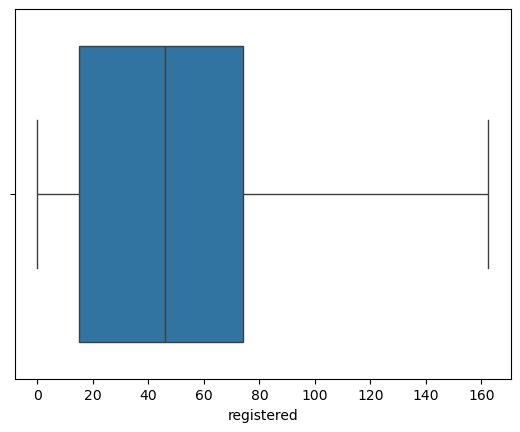

In [135]:
sns.boxplot(x=final_data['registered'])

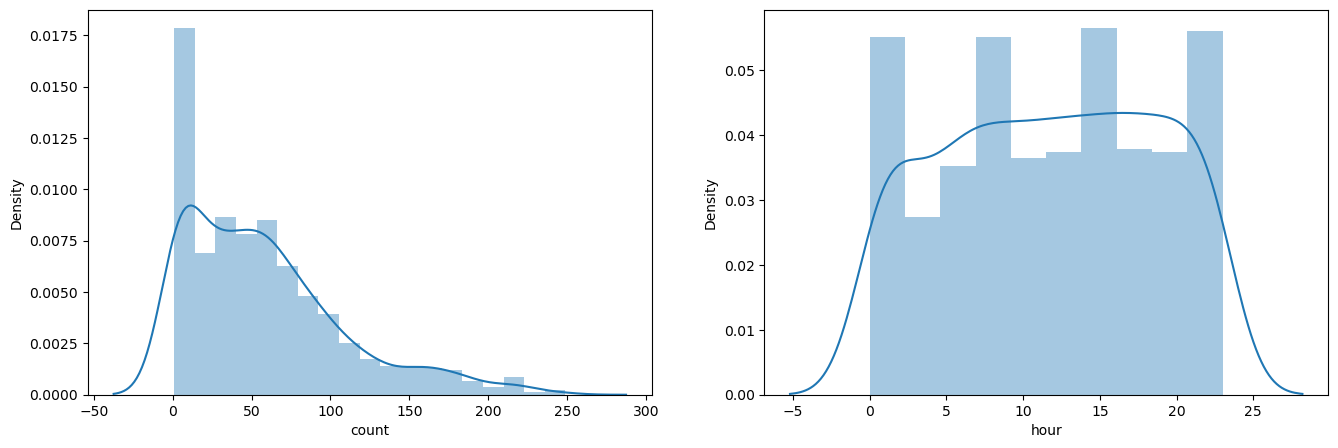

<Axes: >

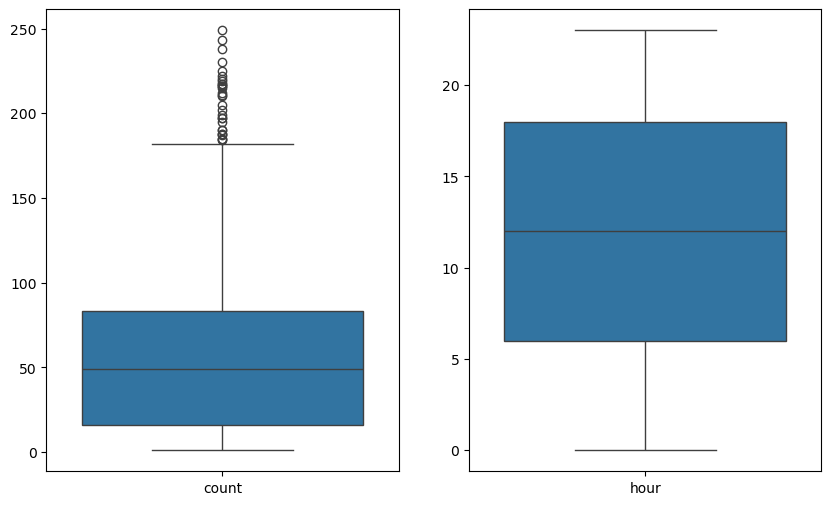

In [136]:
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.distplot(final_data['count'])

plt.subplot(1,2,2)
sns.distplot(final_data['hour'])
plt.show()

fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(10,6))
sns.boxplot(data=final_data[['count']],ax=ax1)
sns.boxplot(data=final_data[['hour']],ax=ax2)

In [137]:
final_data['count'].describe()

count    1000.000000
mean       58.304000
std        50.985558
min         1.000000
25%        16.000000
50%        49.000000
75%        83.000000
max       249.000000
Name: count, dtype: float64

In [138]:
final_data['count'].skew()

1.1377091237001284

In [139]:
print("Mean value of count",final_data["count"].mean())
print("std deviation of count",final_data["count"].std())

Mean value of count 58.304
std deviation of count 50.9855578679994


### Capping Outliers

In [140]:
Q1 = final_data['count'].quantile(0.25)
Q3 = final_data['count'].quantile(0.75)
IQR = Q3-Q1
upper_limit = Q3 + 1.5*IQR
lower_limit = Q1 - 1.5*IQR

print(Q1)
print(Q3)
print(IQR)
print(upper_limit)
print(lower_limit)

16.0
83.0
67.0
183.5
-84.5


In [141]:
final_data["count"]=np.where(
    final_data["count"]>upper_limit,
    upper_limit,
    np.where(
        final_data["count"]<lower_limit,
                         lower_limit,
        final_data["count"]))

<Axes: xlabel='count'>

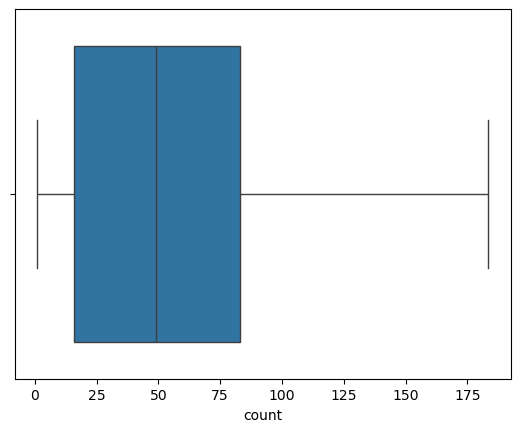

In [142]:
sns.boxplot(x=final_data['count'])

### Find the ovservations on the basis of colums

In [143]:
final_data['registered'].sum()

52075.5

In [144]:
final_data.groupby('holiday')['registered'].sum().round(0)

holiday
False    51192.0
True       883.0
Name: registered, dtype: float64

# BarPlot

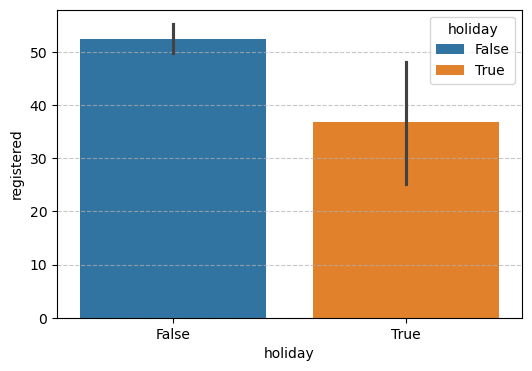

In [145]:
plt.figure(figsize=(6,4))
plt.grid(axis='y', linestyle='--', alpha=0.7)
sns.barplot(x='holiday',y='registered',data=final_data,hue='holiday')
plt.show()

### Insight basis of holiday and registered

#### 1. We can see here that when the holiday false, more users are registered.

#### 2. We can see here that when the holiday is true then less times users are registered.

## ScatterPlot

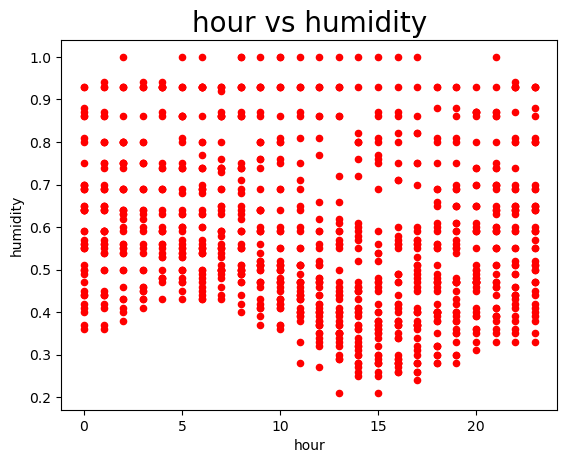

In [146]:
final_data.plot(x='hour',y='humidity',kind='scatter',color='red',)
plt.title('hour vs humidity',fontsize=20)
plt.show()

##Daily Humidity Cycle: The scatter plot shows how humidity levels change throughout the day. From the visualization, we observe that:

Early Morning: Humidity is relatively high during the early morning hours.

Midday Dip:

There's a noticeable dip in humidity around the middle of the day (between 10 AM to 3 PM).

Late Evening:

Humidity levels rise again during the late evening hours.

Humidity Patterns: 
    
The plot suggests that humidity is generally lower during the daytime and higher during nighttime. 
This pattern is typical as the temperature during the day can cause humidity to decrease, while cooler evening temperatures can increase humidity.




In [147]:
correlation = final_data['temp'].corr(final_data['humidity'])
print(f"Correlation between temperature and user count: {correlation}")


Correlation between temperature and user count: 0.06744685138051222


## Scatter plot 'temp vs humidity'

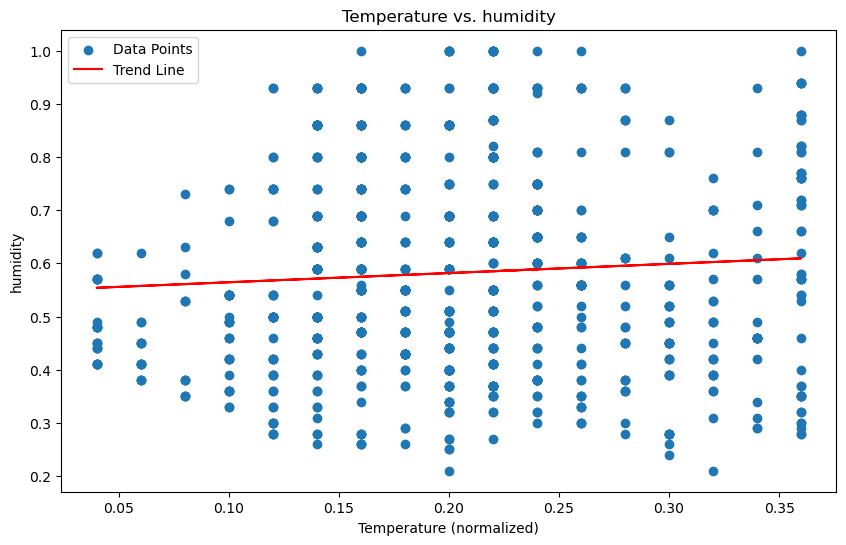

In [148]:
# Scatterplot
plt.figure(figsize=(10, 6))
plt.scatter(final_data['temp'], final_data['humidity'], label='Data Points')

# Fit line
m, b = np.polyfit(final_data['temp'], final_data['humidity'], 1)
plt.plot(final_data['temp'], m * final_data['temp'] + b, color='red', label='Trend Line')

plt.title('Temperature vs. humidity')
plt.xlabel('Temperature (normalized)')
plt.ylabel('humidity')
plt.legend()
plt.show()


Positive Correlation: 

The trend line indicates a slight positive correlation between temperature and humidity.
This means that as the temperature increases, the humidity tends to increase as well.

General Pattern: 

Despite some scattering, the general pattern suggests that warmer temperatures are associated with higher humidity levels. 
This insight is valuable for understanding how temperature variations might influence humidity in a given environment.

Potential Implications:

Comfort Levels: Higher temperatures with higher humidity might lead to uncomfortable and muggy weather conditions.


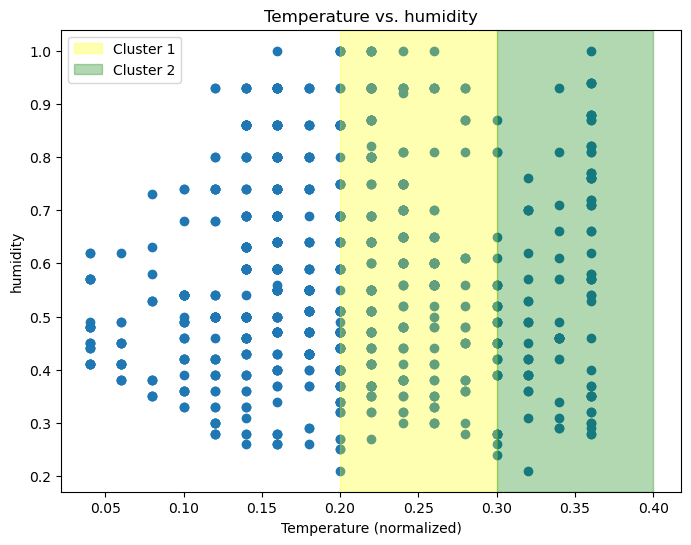

In [149]:
plt.figure(figsize=(8, 6))
plt.scatter(final_data['temp'], final_data['humidity'])

# Highlight clusters (for illustration; actual clustering can use algorithms like KMeans)
plt.axvspan(0.2, 0.3, color='yellow', alpha=0.3, label='Cluster 1')
plt.axvspan(0.3, 0.4, color='green', alpha=0.3, label='Cluster 2')

plt.title('Temperature vs. humidity')
plt.xlabel('Temperature (normalized)')
plt.ylabel('humidity')
plt.legend()
plt.show()


Cluster Distribution:

Cluster 1 (highlighted in yellow) is primarily concentrated in the temperature range of approximately 0.20 to 0.30.

Cluster 2 (highlighted in green) is primarily concentrated in the temperature range of approximately 0.30 to 0.40. 
This distribution suggests distinct behaviors in humidity at different temperature ranges.

Humidity Variation: 
Both clusters show a wide range of humidity values, indicating significant variability within each temperature range. 
Even within a specific temperature range, humidity can vary widely.

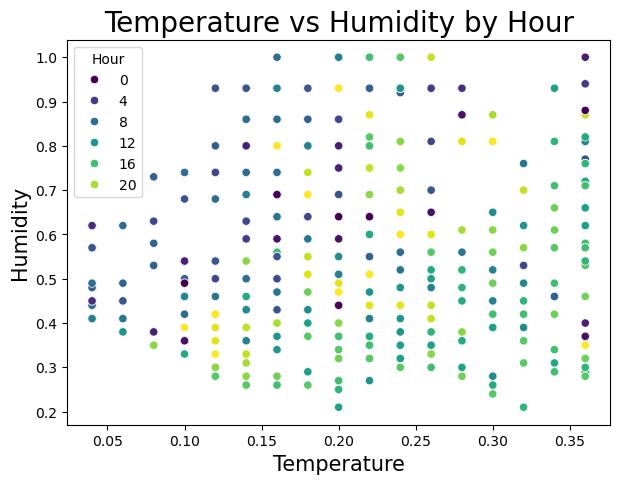

In [150]:
# Scatter plot of temperature vs humidity colored by hour
plt.figure(figsize=(7, 5))
sns.scatterplot(x='temp', y='humidity', hue='hour', data=final_data, palette='viridis')
plt.title('Temperature vs Humidity by Hour', fontsize=20)
plt.xlabel('Temperature', fontsize=15)
plt.ylabel('Humidity', fontsize=15)
plt.legend(title='Hour')
plt.show()


Insights from the Scatter Plot
Positive Correlation: The scatter plot indicates a positive correlation between temperature and humidity. As the temperature increases, the humidity also tends to increase. This relationship is consistent across different hours of the day.

Hourly Variations:

Morning Hours (0 - 8 AM): Humidity is generally lower at lower temperatures, but as the temperature starts to increase, so does the humidity.

Afternoon Hours (12 - 4 PM): During these hours, the temperature and humidity are both relatively higher. The scatter points are more spread out, indicating more variability in humidity at higher temperatures.

Evening Hours (8 PM onwards): The temperature starts to decrease, but humidity remains relatively high, maintaining the positive correlation.

Color Coding by Hour: The color coding by hour provides a clear visual understanding of how temperature and humidity change throughout the day. It helps identify specific patterns or trends related to different times of the day.

Clusters:

Early Morning Cluster: This cluster shows lower temperatures with a range of humidity levels.

Late Afternoon/Early Evening Cluster: This cluster shows higher temperatures with higher humidity levels, indicating more uncomfortable weather conditions during these hours.

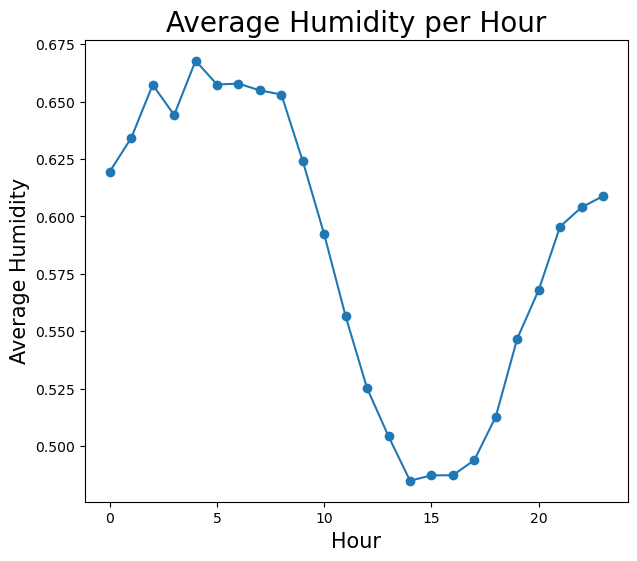

In [151]:
average_humidity = final_data.groupby('hour')['humidity'].mean()

# Plotting the average humidity per hour
plt.figure(figsize=(7, 6))
plt.plot(average_humidity.index, average_humidity.values, marker='o')
plt.title('Average Humidity per Hour', fontsize=20)
plt.xlabel('Hour', fontsize=15)
plt.ylabel('Average Humidity', fontsize=15)
#plt.grid(True)
plt.show()


Insights from the Graph
Early Morning Peak:

Humidity starts relatively high at around 0.625 at hour 0 (midnight).

It continues to increase, reaching a peak of approximately 0.675 between hours 3 and 5 AM.

Midday Dip:

After hour 5 AM, the average humidity gradually decreases.

The lowest point occurs between hours 14 and 16 (2 PM to 4 PM), where the humidity drops to around 0.475.

Late Afternoon Rise:

Post hour 16 (4 PM), the humidity starts to rise again.

By hour 23 (11 PM), the average humidity returns to around 0.625.

## LinePlot

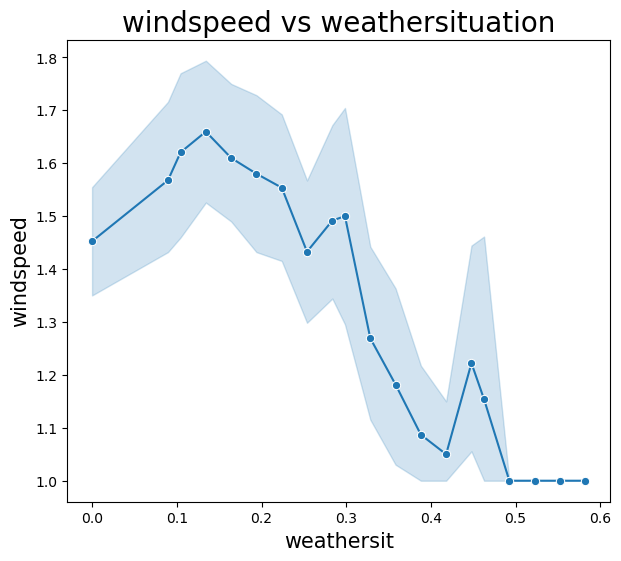

In [152]:
# Create a line plot
plt.figure(figsize=(7, 6))
sns.lineplot(x='windspeed', y='weathersit', data=final_data, marker='o')

plt.title('windspeed vs weathersituation', fontsize=20)
plt.xlabel('weathersit', fontsize=15)
plt.ylabel('windspeed', fontsize=15)
#plt.grid(True)
plt.show()


Insights from the Graph
Initial Increase:

As the "weathersit" value increases from 0.0 to around 0.2, the windspeed shows a notable increase, peaking at around 1.7. This indicates that the windspeed is generally higher in the early stages of "weathersit."

Subsequent Decrease:

After reaching the peak, the windspeed begins to decrease as the "weathersit" value continues to rise. This indicates a decrease in windspeed for higher "weathersit" values, with some fluctuations.

Variability:

The shaded area around the line suggests variability in the windspeed measurements, with wider intervals at certain points. This indicates that the windspeed values are not consistent and can vary significantly within specific "weathersit" ranges.

Trend Observation:

Overall, the graph suggests that there is a specific "weathersit" range (approximately 0.2) where the windspeed is at its highest. Beyond this range, the windspeed generally decreases, indicating that certain weather situations might lead to lower windspeed.

## Pie Chart

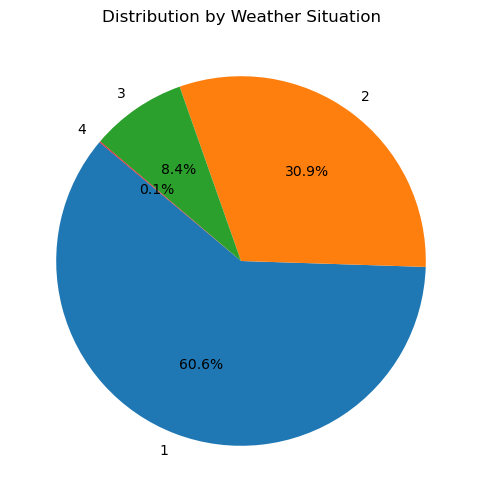

In [159]:
weathersit_counts = final_data['weathersit'].value_counts()
labels = ['1', '2', '3', '4']

plt.figure(figsize=(7, 6))
plt.pie(weathersit_counts, labels=labels, autopct='%1.1f%%', startangle=140)
plt.title('Distribution by Weather Situation')
plt.show()


## Insight of chart

Clear Weather (Segment 1 - Blue): This is the largest segment, representing 60.6% of the data. This suggests that the majority of the time, the weather was clear.

Mist (Segment 2 - Orange): The second largest segment, making up 30.9% of the data. This indicates that misty conditions were fairly common.

Light Rain/Snow (Segment 3 - Green): This segment accounts for 8.4% of the data. While less frequent than clear or misty conditions, light rain or snow still occurred occasionally.

Heavy Rain/Snow (Segment 4 - Thin Slice): The smallest segment, representing only 0.1% of the data. This implies that heavy rain or snow was very rare.

## Line Chart

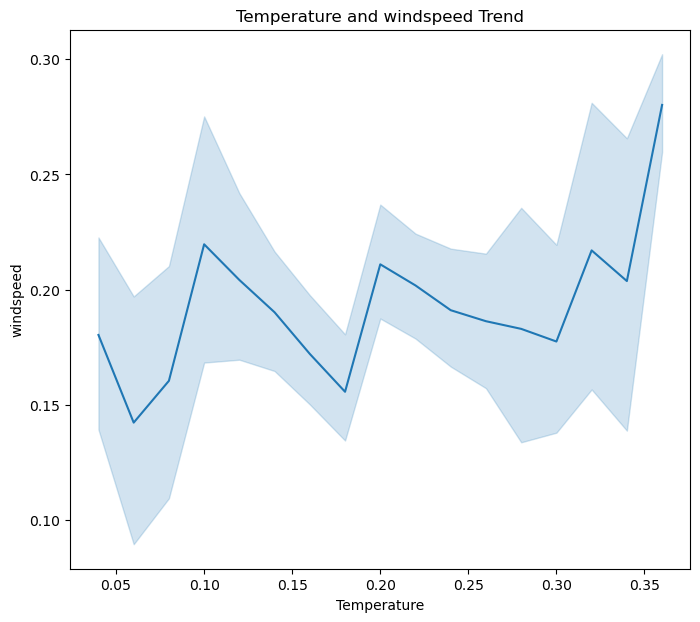

In [154]:
plt.figure(figsize=(8, 7))
sns.lineplot(data=final_data, x='temp', y='windspeed',)
plt.title('Temperature and windspeed Trend')
plt.xlabel('Temperature')
plt.ylabel('windspeed')
plt.show()


#Fluctuating Windspeed: As the temperature changes, there are noticeable fluctuations in wind speed, with peaks and troughs indicating variability.

Variability Range: The shaded area around the line represents the confidence interval or the variability range in wind speed measurements at different temperatures. This indicates that wind speed can vary significantly at certain temperature ranges.

Relationship: The overall trend suggests a relationship between temperature and wind speed, which can be useful for understanding weather patterns or for scientific analysis.

## Heatmap

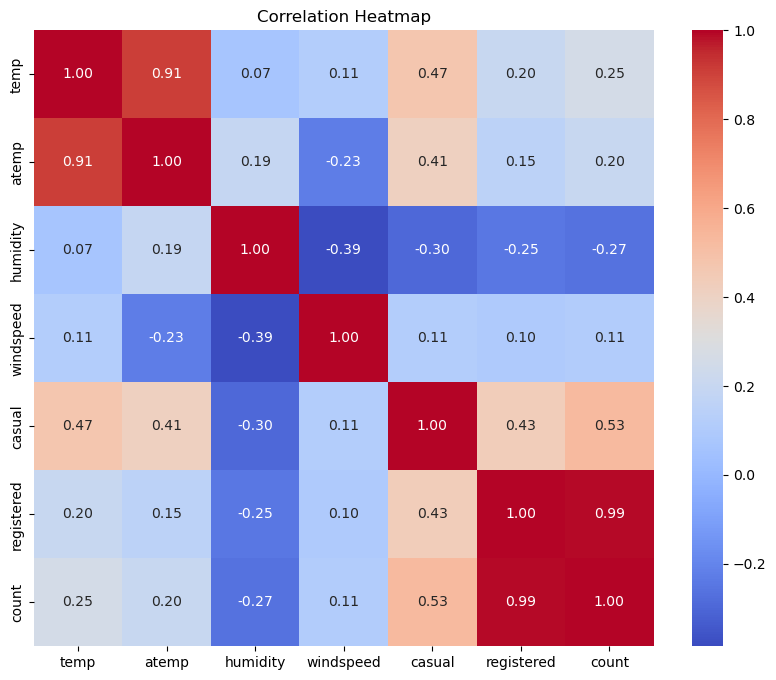

In [155]:
heatmap_data = final_data[['temp', 'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count']]

plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_data.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()


## Insights and Correlations

Strong Positive Correlations:

temp and atemp have a very high positive correlation (0.91), indicating that as the actual temperature increases, the apparent temperature also increases.

registered and count have an almost perfect positive correlation (0.99), which makes sense as the total count is highly influenced by the number of registered users.

casual and count also have a strong positive correlation (0.53), showing that casual user counts significantly contribute to the total count.

registered and casual have a moderate positive correlation (0.43), suggesting that when registered user counts increase, casual user counts tend to increase as well.

Moderate Positive Correlations:

temp and casual (0.47), meaning that higher temperatures tend to attract more casual users.

atemp and casual (0.41), indicating a similar trend as with the actual temperature.

Weak Positive Correlations:

temp and count (0.25), suggesting a slight positive impact of temperature on the total count.

atemp and count (0.20), indicating a similar slight impact of apparent temperature.

temp and registered (0.20), showing a minor positive correlation.

atemp and registered (0.15), indicating a slight positive trend.

Negative Correlations:

humidity and windspeed have a moderate negative correlation (-0.39), suggesting that higher humidity tends to coincide with lower wind speeds.

humidity and casual (-0.30), indicating that higher humidity deters casual users.

humidity and registered (-0.25), showing that higher humidity might negatively impact registered users.

humidity and count (-0.27), suggesting that higher humidity negatively impacts the total user count.

atemp and windspeed (-0.23), indicating a slight negative relationship.

Weak or No Correlations:

temp and humidity (0.07), showing almost no correlation.

temp and windspeed (0.11), indicating a very weak positive correlation.

atemp and humidity (0.19), showing a slight positive correlation.

windspeed and casual (0.11), indicating a weak positive correlation.

windspeed and registered (0.10), showing a weak positive correlation.

windspeed and count (0.11), indicating a weak positive correlation.

Key Takeaways:
Temperature and apparent temperature are closely related and positively influence user counts, especially casual users.

Humidity generally has a negative impact on user counts, both casual and registered.

Registered users have a very strong influence on the total user count.

Windspeed shows moderate negative correlations with humidity and slight positive correlations with user counts.

## Histplot

<Axes: ylabel='Count'>

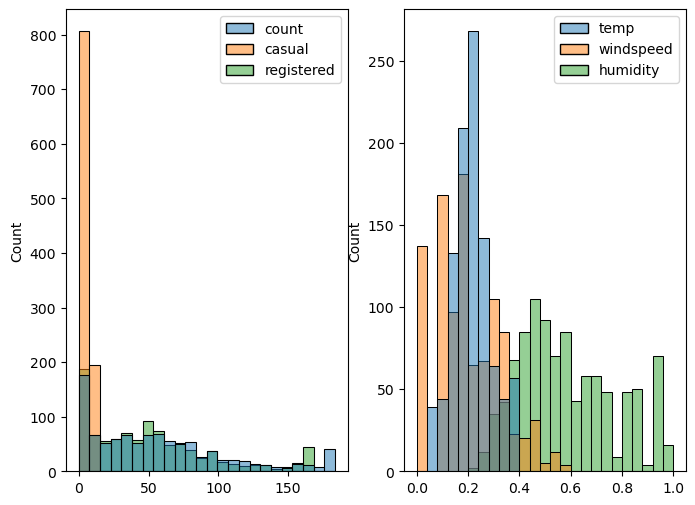

In [156]:
fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(8,6))
sns.histplot(data=final_data[['count','casual','registered']],ax=ax1)
sns.histplot(data=final_data[['temp','windspeed','humidity']],ax=ax2)

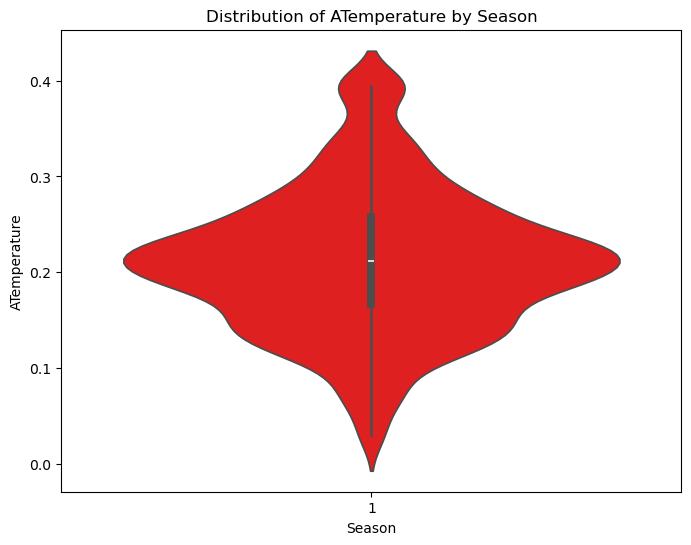

In [157]:
plt.figure(figsize=(8, 6))
sns.violinplot(x='season', y='atemp', data=final_data,color='red')
plt.title('Distribution of ATemperature by Season')
plt.xlabel('Season')
plt.ylabel('ATemperature')
plt.show()


## Insight

Symmetrical Distribution: The distribution of "ATemperature" for season 1 appears to be relatively symmetrical, indicating a balanced spread of temperature values around the center.

High Density Around Median: The density of "ATemperature" values is highest around the middle of the range. This suggests that most temperature values are concentrated around the median, which can be seen in the wider part of the violin plot.